In [10]:
import cv2
import math
import matplotlib.pyplot as plt
import numpy as np

MODEL_PATH = r"C:\Users\I use nvim btw46\bluesense_pore_pp\src\landmark_parse\face_landmarker_v2_with_blendshapes.task"

class PathError(Exception):
    pass

def resize_and_show(image_path : str=None, image : np.ndarray = None, image_height = 748, image_width = 640):

  if image_path is not None and image is not None:
    print("Give either a path to the image, or a cv2.imread image")
    return ValueError    
  elif image_path is None and image is None:
    print("Give either a path to the image, or a cv2.imread image")
    return ValueError
  elif image_path is not None:
    image = cv2.imread(image_path)

  
    
  h, w = image.shape[:2]
  if h < w:
    img = cv2.resize(image, (image_width, math.floor(h/(w/image_height))))
  else:
    img = cv2.resize(image, (math.floor(w/(h/image_height)), image_height))
  plt.imshow(image)
  plt.axis('off')
  plt.show()

# resize_and_show(IMAGE)

In [11]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles

In [12]:
def draw_landmarks_on_image(rgb_image, detection_result):
  face_landmarks_list = detection_result.face_landmarks
  annotated_image = np.copy(rgb_image)

  # Loop through the detected faces to visualize.
  for idx in range(len(face_landmarks_list)):
    print(face_landmarks_list[idx])
    face_landmarks = face_landmarks_list[idx]

    # Draw the face landmarks.

    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION,
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_tesselation_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS,
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_contours_style())

  return annotated_image

def plot_face_blendshapes_bar_graph(face_blendshapes):
  # Extract the face blendshapes category names and scores.
  face_blendshapes_names = [face_blendshapes_category.category_name for face_blendshapes_category in face_blendshapes]
  face_blendshapes_scores = [face_blendshapes_category.score for face_blendshapes_category in face_blendshapes]
  # The blendshapes are ordered in decreasing score value.
  face_blendshapes_ranks = range(len(face_blendshapes_names))

  fig, ax = plt.subplots(figsize=(12, 12))
  bar = ax.barh(face_blendshapes_ranks, face_blendshapes_scores, label=[str(x) for x in face_blendshapes_ranks])
  ax.set_yticks(face_blendshapes_ranks, face_blendshapes_names)
  ax.invert_yaxis()

  # Label each bar with values
  for score, patch in zip(face_blendshapes_scores, bar.patches):
    plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

  ax.set_xlabel('Score')
  ax.set_title("Face Blendshapes")
  plt.tight_layout()
  plt.show()

In [19]:
def get_annotated_image_and_detection_result(image_path):
    # Create an FaceLandmarker object.
    base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
    options = vision.FaceLandmarkerOptions(base_options=base_options,
                                        output_face_blendshapes=True,
                                        output_facial_transformation_matrixes=True,
                                        num_faces=1)
    detector = vision.FaceLandmarker.create_from_options(options)

    # Load the input image.
    image = mp.Image.create_from_file(image_path)

    # Detect face landmarks from the input image.
    detection_result = detector.detect(image)

    if detection_result.face_landmarks == []:
        raise ValueError("No face found on image!")

    # Process the detection result
    annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
    return annotated_image, detection_result

annotated_image, detection_result = get_annotated_image_and_detection_result("iamge.png")

resize_and_show(image=annotated_image)

ValueError: No face found on image!

In [ ]:
plot_face_blendshapes_bar_graph(detection_result.face_blendshapes[0])

IndexError: list index out of range

In [ ]:
print(detection_result.facial_transformation_matrixes)

[array([[ 9.9221110e-01, -6.0493909e-02,  1.0888996e-01,  1.1876132e+00],
       [ 9.1041721e-02,  9.4880080e-01, -3.0247086e-01,  2.2372683e+01],
       [-8.5017204e-02,  3.1002861e-01,  9.4691849e-01, -6.8015167e+01],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  1.0000000e+00]],
      dtype=float32)]


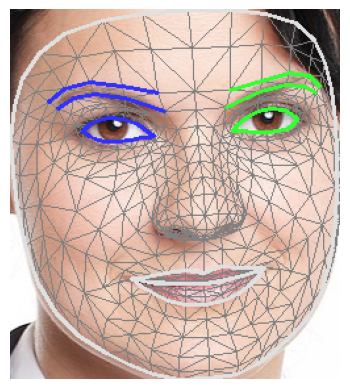

In [ ]:
def crop_to_face(image_rgb, detection_result, padding_ratio=0.2):
    h, w = image_rgb.shape[:2]

    # detection_result.face_landmarks is a list of faces; take the first
    landmarks = detection_result.face_landmarks[0]

    # convert normalized (0-1) landmark coords -> pixel coords
    xs = [lm.x * w for lm in landmarks]
    ys = [lm.y * h for lm in landmarks]

    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    # add padding around the tight box (landmarks hug the face closely,
    # a bit of margin avoids cutting off jaw/forehead edges)
    box_w = x_max - x_min
    box_h = y_max - y_min
    pad_x = box_w * padding_ratio
    pad_y = box_h * padding_ratio

    x_min = max(0, int(x_min - pad_x))
    y_min = max(0, int(y_min - pad_y))
    x_max = min(w, int(x_max + pad_x))
    y_max = min(h, int(y_max + pad_y))

    return image_rgb[y_min:y_max, x_min:x_max]

face_crop = crop_to_face(annotated_image, detection_result=detection_result, padding_ratio=0)

resize_and_show(image=face_crop)